In [ ]:
import pandas as pd
import numpy as np

In [ ]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv'
col_names = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin',
             'BMI','DiabetesPedigreeFunction','Age','Outcome']
data = pd.read_csv(url, header=None, names=col_names)
print(data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


(데이터 불러오기 단계)
kaggle 이 아니고 다른 출처 데이터라 컬럼명 없으므로 직접 col_names 로 컬럼 이름 붙여줌
data.head()로 첫 5줄 출력해 데이터 구조 확인

In [ ]:
for col in ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']:
    data[col].replace(0, np.nan, inplace=True)
    data[col].fillna(data[col].mean(), inplace=True)

data.isnull().sum()

/tmp/ipython-input-396010830.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].replace(0, np.nan, inplace=True)
/tmp/ipython-input-396010830.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


전처리를 수행한 5개 컬럼:

Glucose

BloodPressure

SkinThickness

Insulin

BMI

이 변수들에만 전처리를 한 이유는 이 5개 변수만 0이 ‘실제 값이 아닌 오류값(결측치)’이기 때문
이유?
혈당(Glucose) = 0 → 사람이 살아 있을 수 없음

혈압(BloodPressure) = 0 → 심장 멈춘 상태

BMI = 0 → 존재 불가능

피부두께(SkinThickness) = 0 → 생리적으로 불가능

인슐린(Insulin) = 0 → 정상 생리에서 거의 불가능

따라서 0은 실제 측정값이 아니라 ‘측정되지 않음’ 또는 ‘기록 누락’이 됨.
5개 변수에 0 은 존재 불가 따라서 결측치(NaN)로 처리.. 그리고(NaN)을 각 변수 평균값으로 채움
(모델학습 방해 안됨)

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop('Outcome', axis=1)
y = data['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

데이터에서 **모델 입력 변수(X)**와 **예측 대상(y, Outcome)**를 분리

전체 데이터를 **학습용 80% / 테스트용 20%**로 나눔
학습/테스트 데이터에서 클래스 비율을 원본과 동일하게 유지함으로 불균형으로 인한 성능 편향을 방지, 결과가 항상 동일하게 재현되도록 데이터 분할 순서를 고정


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


스케일러 객체 생성: 평균 0, 표준편차 1로 바꿔줌
각 컬럼 값 -1 ~ 1, 0 중심으로 변함..
여기서 -1,1,0이란:
표준화된 값 -1은 원래 값이 해당 변수 평균보다 1표준편차만큼 낮음을 의미하며, 0은 평균과 같고, 1은 평균보다 1표준편차 높음을 나타냄”
이유? 예를 들면 glucose 값은 80-130 사이고 bmi 값은 20-35 사이, 이와같이 범위가 크면 모델이 일부 변수에 편향되어 학습될 수 있음
X_train_scaled -> 학습 데이터의 평균과 표준편차를 계산 후 변환
X_test_scaled-> 테스트 데이터는 학습 데이터 통계값(mean, std) 기준으로 변환
를 통해 모델 학습 안정성과 예측 성능을 향상시킬 수 있음.


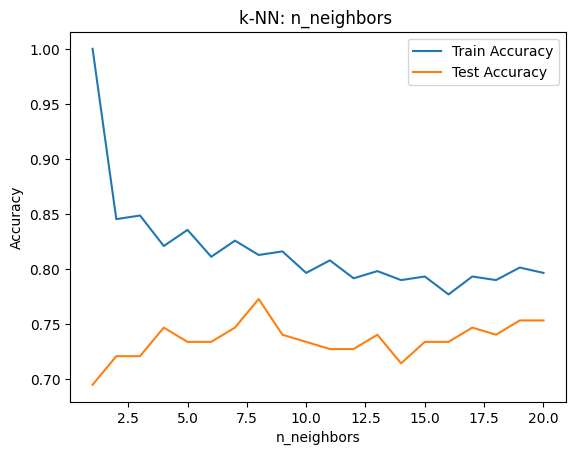

테스트 세트에서 가장 높은 정확도를 내는 k: 8


KNeighborsClassifier(n_neighbors=np.int64(8))

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

train_scores = []
test_scores = []

for k in range(1, 21):
    kn = KNeighborsClassifier(n_neighbors=k)
    kn.fit(X_train_scaled, y_train)
    train_scores.append(kn.score(X_train_scaled, y_train))
    test_scores.append(kn.score(X_test_scaled, y_test))

plt.plot(range(1, 21), train_scores, label='Train Accuracy')
plt.plot(range(1, 21), test_scores, label='Test Accuracy')
plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.title('k-NN: n_neighbors ')
plt.legend()
plt.show()

best_k = np.argmax(test_scores) + 1
print(f"테스트 세트에서 가장 높은 정확도를 내는 k: {best_k}")

# 최적 k 모델
kn_best = KNeighborsClassifier(n_neighbors=best_k)
kn_best.fit(X_train_scaled, y_train)

k-NN 모델을 1부터 20까지 k 값으로 반복 학습

학습 데이터와 테스트 데이터에서 정확도(accuracy) 측정

k 값에 따른 정확도 변화를 그래프로 시각화

테스트 데이터에서 가장 높은 정확도를 내는 k 값 선택 - 8

최적 k로 다시 학습하여 최종 모델(kn_best) 생성

 k가 너무 작으면 (예: 1, 2)
 주변 몇 개에 너무 민감 → 과적합 위험

k가 너무 크면 (예: 15 이상)
 너무 많이 평균내버림 → 패턴 놓침 → 과소적합 위험


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53916 (\N{HANGUL SYLLABLE TYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45789 (\N{HANGUL SYLLABLE NING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


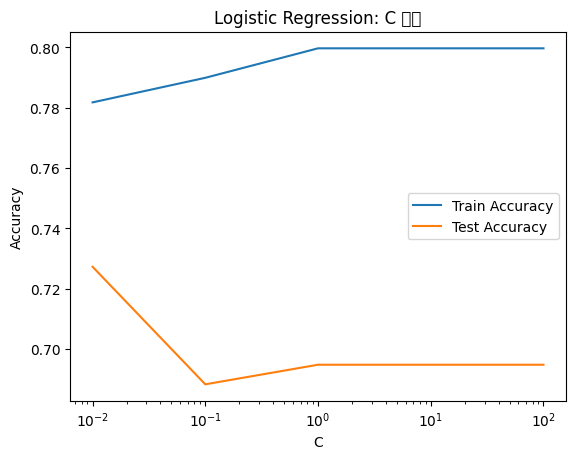

테스트 세트에서 가장 높은 정확도를 내는 C: 0.01


LogisticRegression(C=0.01, max_iter=1000, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

train_scores_lr = []
test_scores_lr = []
C_values = [0.01, 0.1, 1, 10, 100]

for C in C_values:
    lr = LogisticRegression(C=C, max_iter=1000, random_state=42)
    lr.fit(X_train_scaled, y_train)
    train_scores_lr.append(lr.score(X_train_scaled, y_train))
    test_scores_lr.append(lr.score(X_test_scaled, y_test))

plt.plot(C_values, train_scores_lr, label='Train Accuracy')
plt.plot(C_values, test_scores_lr, label='Test Accuracy')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title('Logistic Regression: C 튜닝')
plt.legend()
plt.show()

best_C = C_values[np.argmax(test_scores_lr)]
print(f"테스트 세트에서 가장 높은 정확도를 내는 C: {best_C}")

lr_best = LogisticRegression(C=best_C, max_iter=1000, random_state=42)
lr_best.fit(X_train_scaled, y_train)

Logistic Regression 모델을 **다양한 C 값(0.01, 0.1, 1, 10, 100)**으로 반복 학습

학습 데이터와 테스트 데이터에서 정확도(accuracy) 측정

C 값에 따른 정확도 변화를 그래프로 시각화

테스트 데이터에서 가장 높은 정확도를 내는 C 값 선택

최적 C 값으로 다시 학습하여 최종 모델(lr_best) 생성

Logistic Regression에서 C는 규제 강도를 조절하는 하이퍼파라미터

C가 작으면 → 규제 강함 → 과소적합 가능

C가 크면 → 규제 약함 → 과적합 가능

후보값 선택 (0.01, 0.1, 1, 10, 100)

다양한 범위를 로그 스케일로 선택
이유? 만약 **등간격(C=0.01,0.25,0.5,0.75,1)**으로만 선택하면

큰 값 영역(10,100 등)을 테스트 못 해서 최적값을 놓칠 수 있음

로그 스케일로 선택하면 작은 값과 큰 값 모두 탐색 가능
작은 값에서 큰 값까지 테스트하여 모델 성능이 가장 좋은 C를 찾기 위함

즉, 0.01은 강한 규제, 100은 거의 규제가 없는 상태를 의미

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

def evaluate_model(model, X_train, y_train, X_test, y_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    roc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    print(f"Accuracy: {acc:.3f}, ROC-AUC: {roc:.3f}")
    print("Confusion Matrix:\n", cm)
    return y_pred

print("=== k-NN 평가 ===")
y_pred_kn = evaluate_model(kn_best, X_train_scaled, y_train, X_test_scaled, y_test)

print("=== Logistic Regression 평가 ===")
y_pred_lr = evaluate_model(lr_best, X_train_scaled, y_train, X_test_scaled, y_test)

=== k-NN 평가 ===
Accuracy: 0.773, ROC-AUC: 0.795
Confusion Matrix:
 [[87 13]
 [22 32]]
=== Logistic Regression 평가 ===
Accuracy: 0.727, ROC-AUC: 0.799
Confusion Matrix:
 [[86 14]
 [28 26]]


sklearn.metrics는 Scikit-learn 라이브러리에서 “모델 성능(평가)을 위한 지표 함수를 모아놓은 모듈(metric module)


accuracy_score : 정확도 계산

confusion_matrix : 혼동 행렬 생성

roc_auc_score : ROC-AUC 점수 계산 (분류 모델 평가 지표)

k-NN 결과 해석:
정확도: k-NN 모델은 테스트 데이터에서 약 77% 정도 정확하게 예측

ROC-AUC: 79.5% 정도의 확률로 모델이 양성과 음성을 잘 구분

Confusion Matrix (혼동행렬):
TN (True Negative) = 87 → 정상인데 정상으로 맞춤

FP (False Positive) = 13 → 정상인데 이상으로 잘못 예측

FN (False Negative) = 22 → 이상인데 정상으로 잘못 예측

TP (True Positive) = 32 → 이상인데 이상으로 맞춤

k-NN 모델은 정상 데이터를 잘 맞추지만, 이상 데이터 일부를 놓치거나 잘못 분류하는 경우가 있습니다.
특히 FN이 22로, 실제 이상 데이터를 정상으로 예측한 경우가 비교적 많음

Logistic Regression:
정확도: 전체 정확도가 72% 정도로 k-NN보다 낮음

ROC-AUC: 79.9%로 k-NN과 거의 비슷, 클래스 구분 능력은 거의 동일합니다
TN = 86 → 정상 맞춤

FP = 14 → 정상 잘못 예측

FN = 28 → 이상 놓침

TP = 26 → 이상 맞춤
Logistic Regression은 이상 데이터를 놓친 경우(FN)가 28로 k-NN보다 많음
정상 데이터 예측 정확도(TN)는 비슷하지만, 이상 데이터 예측 능력(TP)은 k-NN보다 낮음

결론: 따라서 테스트 데이터에서 이상을 잘 탐지하려면 k-NN 모델이 더 적합
